In [1]:
# Capstone -- function 7 (6D)

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.spatial import Delaunay, ConvexHull
from scipy.stats import spearmanr

from bayes_tools import (
    load_collected, save_proposal,
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_kappa_proposals, print_kappa_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration, plot_kappa_sensitivity,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 7

6D, 33 observations (30 initial + weeks 2–4), all of them in the fit. Search domain is the unit cube `[0,1]^6`.

I propose with **`exploit`** — UCB at `kappa = 0` — over the four live axes {x0, x3, x4, x5}, holding x1 and x2 at the incumbent: **`[0.044754, 0.491672, 0.247422, 0.197315, 0.394860, 0.719635]`** (GP mean +1.3713, std 0.0515). The predicted improvement is **−0.003**. That is deliberate, not an oversight — see "this function looks converged" below.

## The peak is real, and my model now explains it

| week | y | note |
|---|---|---|
| 2 | 0.000309 | out of domain on 4 of 6 axes; worst on record |
| 3 | **1.374343** | incumbent |
| 4 | 1.327096 | 0.015 from the incumbent |

Both of these **retire arguments I was relying on last week**:

- I had written that *"the incumbent is a point the model cannot explain… predicted at 0.203 ± 0.086 against a true 1.365 — a roughly 13.5 sigma miss"*, and used it to justify a small local step. On current data, held out, the incumbent predicts **+1.3324 ± 0.0409 against 1.3743, so z = +1.0**. Fully explained.
- Week 4 landed 0.015 away and returned 1.3271, so **two independent measurements now confirm the region is genuinely high**. The peak no longer rests on one unexplained point, and its neighbourhood is mapped.

## x1 and x2 are settled — on three independent tests

I hold them at the incumbent. That was worth re-examining, because a pinned axis can be self-reinforcing, but here it is not:

- **My initial design sweeps them.** x1 spans [0.012, 0.925] and x2 [0.004, 0.925] over 30 points, so this is not a case where every observation sits on one line.
- **Model-free:** among pairs similar on the live axes, mean \|Δy\| is **0.1165** when x1/x2 are close and **0.1190** when far apart — indistinguishable, against a `y` std of 0.3977. No GP involved.
- **There is nothing for the GP to learn there.** Moving x1/x2 to the domain corners raises posterior std only **1.0–1.5×** and moves the predicted mean by −0.001 to −0.008.

ARD pins both at the 10.0 ceiling, stably across refits, with **275× less** mean-variation than the largest axis. Testing them would spend a week confirming what three separate lines of evidence already agree on.

## Why `exploit`, and why my previous criterion had to go

My old rationale was *"the largest kappa that touches no bound at all, upper or lower"*, which rested on upper-bound contact meaning `pad_fraction` had chosen the coordinate. **Bounds are the true domain `[0,1]` now**, so upper contact would mean the constrained optimum really is on the boundary. That criterion is void — and on this week's data it does not even discriminate: `kappa` 0, 0.25, 0.5 and 1.0 all touch nothing, so it would have picked 1.0.

The replacement I use on function 6 — *the largest `kappa` whose predicted mean still beats the incumbent* — **has no answer here.** Every value loses:

| kappa | pred. mean | gain vs incumbent | step |
|---|---|---|---|
| **0 (= `exploit`)** | **+1.37126** | **−0.00308** | 0.051 |
| 0.25 (my previous choice) | +1.37002 | −0.00432 | 0.060 |
| 0.5 | +1.36576 | −0.00858 | 0.069 |
| 1.0 | +1.34670 | −0.02764 | 0.084 |

So `kappa = 0` is the value that loses *least*. Same criterion as function 6, opposite outcome — which is exactly why I apply it per function rather than inheriting a number.

## This function looks converged

- **Exploitation is exhausted**: no `kappa` predicts a gain.
- **Exploration has nothing targeted to offer.** Every in-domain gap on every live axis is interpolable — x0 0.098/1.039 (ratio 0.09), x3 0.090/0.382 (0.23), x4 0.088/0.208 (0.43), x5 0.129/0.256 (0.50). Scanning x3 shows the mean falling monotonically from +1.356 at x3=0.23 to +0.177 at x3=0.94, so there is no hidden structure to go after.

  *(Computed over **all** points the x3 ratio reads 1.85 and looks unresolved. That is an artefact: the gap runs from x3=0.961 to the out-of-domain 1.668, so most of it is unreachable. Gaps have to be computed on in-domain points only.)*
- **Exploration is expensive here.** Posterior std at the incumbent is 0.0346 against a live-subspace median of 0.2105, so buying uncertainty reduction costs roughly 0.9–1.4 of expected `y` on a function whose entire range is 0.0003–1.374: `ucb k=2` predicts +1.2717, `k=5` +0.9948, `max_variance` **+0.2339**.

`exploit` banks a −0.003 step that also sharpens the peak. If it fails to beat 1.374343, that is the point to decide *deliberately* whether to pay for exploration — not to reach for a smaller `kappa`.

## Notes

- **`xi` is a live dial**: EI's proposal moves 0.342 then 1.398 as `xi` rises from 0.1% to 100% of the `y` spread. But EI and PI both degrade the predicted mean, down to +0.535, so they are variance-seeking here rather than degenerate.
- **The backtest agrees, and its two leaders disagree with each other.** `exploit` leads on mean regret (0.1838) while `ucb_k0.25` leads on median (both medians are 0), and the paired gap between them is +0.0019 ± 0.0013 — 1.4 s.e., i.e. noise. What it really supports is "`kappa` at or below 0.5", the three of which are all within noise.
- **No y-scaling.** `kappa` is dimensionless and `exploit` ranks by posterior mean, so both are exactly scale-invariant.
- **The convex-hull test is near-vacuous at D=6** — 32 of 33 observations are hull vertices and the hull is 1.63% of the observed box, so almost any proposal reads as outside it. The per-axis and domain-edge checks carry the weight.
- **The week-2 point stays in the fit** despite being out of domain: across all three collected points the length-scales move only 0.98–1.06×, and its `y` is ordinary rather than a spurious record.
- LOO: 29/33 inside their own 95% interval. The worst-predicted point is **not** the incumbent — it is index 3, from the initial batch, at −4.5 sigma. I had to pin `random_state` in that cell to say this at all: unseeded, 33 multi-restart refits gave a different answer every run (29/33 with index 7 at −2.5σ, then 28/33 with index 3 at −4.5σ).
- `plot_2d_bo` doesn't apply at D=6, so the GP view is `plot_nd_slices`, and the x1/x2 panels are flat by construction. `compute_iteration_diagnostics` needs `domain_grid_n` lowered; its default 40 would build a 4.1e9-point grid.

In [2]:
X_initial = np.load("initial_data/function_7/initial_inputs.npy")
y_initial = np.load("initial_data/function_7/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 6, f"Expected a 6D problem, got {D}D input -- check the loaded file."

# Loaded once and never modified.
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Include the new X and y values from the previous week.

In [3]:
# My collected observations, from weekly_data/function_7/. I run
# record_results.py before opening this notebook so the results are already
# there. pending_X holds a proposal with no result yet; it never reaches the
# model.
#
# Provenance of the collected points, oldest first:
#   - week 2 -- the old sweep proposed
#       [0.273698, 1.11042, 1.04745, 1.667513, -0.629585, 1.119339].
#       That x4 is negative, from bounds built without lower_limit=0.0; it is
#       recorded here with the sign positive, as supplied. Out of domain on 4 of
#       6 axes, and the worst y on record.
#   - week 3 -- back inside the data cloud; this one is my incumbent.
#   - week 4 -- 0.015 from week 3, confirming the region rather than beating it.

new_X, new_y, pending_X = load_collected(7, D)

# Label each row by its own week. This used to print new_y[-1] as "week 3",
# which was right when there was one collected row and silently wrong once
# there were three.
print("observations collected so far:", len(new_y))
_running = y_initial.max()
for r, v in enumerate(new_y):
    tag = "   <- a new best" if v > _running else ""
    print("  week %d y: %.9f%s" % (r + 2, v, tag))
    _running = max(_running, v)
print("best on record: %.6f (the initial batch alone reached %.6f)"
      % (max(y_initial.max(), new_y.max()), y_initial.max()))


weekly store: 3 resulted observation(s), 1 pending proposal [0.044754 0.491672 0.247422 0.197315 0.39486  0.719635]
  NOTE the pending row will be REPLACED when this notebook saves its proposal
observations collected so far: 3
  week 2 y: 0.000308588
  week 3 y: 1.374343402   <- a new best
  week 4 y: 1.327096049
best on record: 1.374343 (the initial batch alone reached 1.364968)


## Build the full dataset (initial + everything collected so far)

In [4]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| combined X shape:", X.shape)
print("y range: %.9f to %.6f (spread %.6f, std %.6f)"
      % (y.min(), y.max(), y.max() - y.min(), y.std()))
for r in range(len(new_y)):
    print("rank of the week-%d observation: %d of %d (1 = best)"
          % (r + 2, int((y > new_y[r]).sum()) + 1, len(y)))

# The domain is the unit cube, so bounds are [0,1] on every axis. lower_limit
# is load-bearing here specifically: without it this function's padded bounds
# went below zero, and my week-2 sweep duly proposed a negative coordinate.
bounds = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0,
                        upper_limit=1.0)
# Week 2 went above 1 before I knew the domain, so it sits outside these bounds.
# I validate the in-domain subset -- catching bounds too narrow for the data is
# what validate_bounds_consistency is for -- and report the rest rather than
# dying on it.
_in_dom = np.all((X >= bounds[:, 0]) & (X <= bounds[:, 1]), axis=1)
validate_bounds_consistency(X[_in_dom], bounds)

if not _in_dom.all():
    print(f"\n{int((~_in_dom).sum())} observation(s) lie OUTSIDE the [0,1] domain,"
          " proposed before it was known:")
    for i in np.flatnonzero(~_in_dom):
        over = [f"x{d}={X[i, d]:.4f}" for d in range(D) if X[i, d] > 1.0]
        print(f"  {', '.join(over)}   y={y[i]:+.5g}")
    print("  It stays IN the fit: its y is ordinary rather than a spurious record,")
    print("  and it barely touches the kernel (see the length-scale ratios below).")
    print("  The search is clamped to [0,1] regardless, so nothing can be proposed")
    print("  out there again.")
print("\nBounds:\n", np.round(bounds, 4))

# How far outside the sampled region did each proposal reach? Week 2 is the
# evidence that extrapolation does not pay on this function; week 3 stayed
# inside and came back the best on record, which reinforces it.
print("\ncollected points vs the INITIAL batch's range:")
n_out_by_week = []
for r in range(len(new_X)):
    n_out = 0
    for d in range(D):
        outside = (new_X[r, d] > X_initial[:, d].max()
                   or new_X[r, d] < X_initial[:, d].min())
        n_out += outside
        print(f"  week {r + 2}  x{d}={new_X[r, d]:.6f}  initial range"
              f" [{X_initial[:, d].min():.4f}, {X_initial[:, d].max():.4f}]"
              f"  outside={outside}")
    n_out_by_week.append(n_out)
    print(f"  -> week {r + 2}: {n_out} of {D} coordinates were extrapolations,"
          f" y={new_y[r]:+.9f}")
# Index the best week rather than assuming it is the last row -- week 4 is the
# last row and it did NOT return the best.
_worst_wk = int(np.argmin(new_y))
_best_wk = int(np.argmax(new_y))
print("-> week %d extrapolated on %d of %d axes and returned the worst y on record;"
      " week %d extrapolated on %d and returned the best."
      % (_worst_wk + 2, n_out_by_week[_worst_wk], D,
         _best_wk + 2, n_out_by_week[_best_wk]))

try:
    hull = Delaunay(X)
    ch = ConvexHull(X)
    box_volume = float(np.prod(X.max(axis=0) - X.min(axis=0)))
    print(f"\nobserved box volume {box_volume:.4g} | convex hull {ch.volume:.4g}"
          f" ({ch.volume / box_volume:.2%} of it)")
    print(f"{len(ch.vertices)} of {len(X)} observations are hull vertices"
          " -- at D=6 almost all are, so the hull test is nearly vacuous here")
except Exception as exc:
    hull = None
    print("\nconvex hull unavailable:", exc)

xi_frac = 0.01 / (y.max() - y.min())
print(f"\nxi=0.01 is {xi_frac:.4%} of the y spread"
      f" -> {'scaling NOT needed' if 0.001 <= xi_frac <= 0.1 else 'CONSIDER y-scaling'}")
print("(kappa is dimensionless, so UCB is unaffected either way)")

X_initial shape: (30, 6) | combined X shape: (33, 6)
y range: 0.000308588 to 1.374343 (spread 1.374035, std 0.397722)
rank of the week-2 observation: 33 of 33 (1 = best)
rank of the week-3 observation: 1 of 33 (1 = best)
rank of the week-4 observation: 3 of 33 (1 = best)

1 observation(s) lie OUTSIDE the [0,1] domain, proposed before it was known:
  x1=1.1104, x2=1.0474, x3=1.6675, x5=1.1193   y=+0.00030859
  It stays IN the fit: its y is ordinary rather than a spurious record,
  and it barely touches the kernel (see the length-scale ratios below).
  The search is clamped to [0,1] regardless, so nothing can be proposed
  out there again.

Bounds:
 [[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]

collected points vs the INITIAL batch's range:
  week 2  x0=0.273698  initial range [0.0579, 0.9425]  outside=False
  week 2  x1=1.110420  initial range [0.0118, 0.9247]  outside=True
  week 2  x2=1.047450  initial range [0.0036, 0.9246]  outside=True
  week 2  x3=1.667513  initial range

## Is the model stable and calibrated?

Two checks.

First, refit on the initial batch alone and predict each collected point. That fit never saw them, so this is a genuine out-of-sample test. All three land inside 1 sigma — including week 2, where the model correctly expected a mediocre value, so the failure that week was my *proposal*, not the surrogate. That is what lets me lean on its posterior mean now.

Second, compare kernels before and after. A length-scale reshaped by one observation would make every variance-driven acquisition untrustworthy. Here they move by 0.98–1.06× and the same two axes stay pinned before and after, so the verdict is stable.

In [5]:
# Both fits first, in one block, so no ConvergenceWarning can land between the
# rows printed below. Two separate blocks here printed two identical reports.
with fitting("before/after fits for the collected observations"):
    gp_before = fit_gp(X_initial, y_initial, bounds, n_restarts_optimizer=25,
                       random_state=0)
    gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=25, random_state=0)

# Fit is the initial batch only, so every collected row is genuinely out of
# sample. The model that actually proposed week 3 also had week 2, so for the
# later rows this understates what was known at proposal time.
mu_b, sd_b = gp_before.predict(normalize(new_X, bounds), return_std=True)
print("out-of-sample test on the collected points (fit = initial batch only):")
for r in range(len(new_X)):
    miss = new_y[r] - mu_b[r]
    print(f"  week {r + 2}: predicted {mu_b[r]:+.6f} +/- {sd_b[r]:.6f}"
          f"   actual {new_y[r]:+.9f}")
    print(f"    miss {miss:+.6f} = {miss / sd_b[r]:+.1f} sigma"
          f"  -> {'well calibrated' if abs(miss / sd_b[r]) < 3 else 'POORLY calibrated'}")
print("  (week 2 read) the model expected a mediocre value there: the proposal")
print("  was the problem, not the surrogate, so its posterior mean is usable.")

ls_before, ls_after = get_length_scales(gp_before), get_length_scales(gp_check)
print("\nkernel before:", gp_before.kernel_)
print("kernel after :", gp_check.kernel_)
print("\nlength-scales before:", np.round(ls_before, 4))
print("length-scales after :", np.round(ls_after, 4))
print("ratio (after/before):", np.round(ls_after / ls_before, 3))

PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit
print("\npinned (GP treats as irrelevant) before:",
      [d for d, v in enumerate(ls_before) if v >= 0.999 * PINNED] or "none")
print("pinned after                          :",
      [d for d, v in enumerate(ls_after) if v >= 0.999 * PINNED] or "none")
print("-> the same axes are pinned before and after, so that verdict is stable")

_move = float(np.max(np.abs(ls_after / ls_before - 1)))
print("largest length-scale move: %.0f%%" % (100 * _move))
if _move > 0.5:
    print("\n*** A length-scale moved by more than 50% across the collected")
    print("    observations. Treat variance-driven acquisitions with suspicion. ***")


[fitting: before/after fits for the collected observations] 4 warnings held back, 2 distinct:
     2 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     2 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
out-of-sample test on the collected points (fit = initial batch only):
  week 2: predicted +0.205674 +/- 0.315736   actual +0.000308588
    miss -0.205366 = -0.7 sigma  -> well calibrated
  week 3: predicted +1.373747 +/- 0.053455   actual +1.374343402
    miss +0.000597 = +0.0 sigma  -> well calibrated
  week 4: predicted +1.372550 +/- 0.044418   actual +1.327096049
    miss -0.045454 = -1.0 sigma  -> well calibrated
  (week 2 read) the model expected a mediocre value there: the proposal
  was the problem, not the surrogate, so its posterior mean is usable.

kernel before: 1.05**2 * Matern(length_scale=[1.06, 10, 10, 0.362, 0.195, 0.246], nu=2.5) + WhiteKernel(noise_level=0.00152)
kernel after : 0.801**2 * Matern(length_sca

## Which axes matter

Length-scales alone aren't sufficient. A length-scale pinned at the 10.0 ceiling means "smooth, nearly linear across this domain", which is not the same as "no effect" — a mild monotone trend can still be there, and if it is, pushing along that axis is a real prediction rather than an optimiser artefact.

So the cell measures GP mean-variation directly, alongside model-free rank correlations, and then applies my flat-axis rule: flat if mean-variation is under 5% of the largest, **or** the length-scale is pinned near the ceiling.

x1 and x2 come back flat on *both* grounds — pinned at the ceiling, and moving the mean **275×** less than the largest axis — which makes this an unusually clear call. Flat axes get held at the incumbent, because a flat acquisition surface makes their coordinates optimiser artefacts.

Note that x1 and x2 still have non-zero rank correlations (−0.107 and +0.148) despite being flat. Not a contradiction: with 33 points in 6D, correlations that small are unremarkable noise, and the GP's own sweep is the more direct measure of whether moving an axis changes the prediction.

In [6]:
incumbent = X[np.argmax(y)]

# Every sweep first, then print, so the comparisons below always see the full
# set of spans rather than a running maximum.
spans = np.zeros(D)       # mean-variation over the full domain
spans_obs = np.zeros(D)   # mean-variation over the observed range only
srho = np.zeros(D)        # Spearman rank correlation with y
for d in range(D):
    for col, (lo, hi) in enumerate([(bounds[d, 0], bounds[d, 1]),
                                    (X[:, d].min(), X[:, d].max())]):
        grid = np.tile(incumbent, (300, 1))
        grid[:, d] = np.linspace(lo, hi, 300)
        m, _ = gp_check.predict(normalize(grid, bounds), return_std=True)
        (spans if col == 0 else spans_obs)[d] = m.max() - m.min()
    srho[d] = spearmanr(X[:, d], y)[0]

print("incumbent (best observed):", np.round(incumbent, 6), " y = %.6f" % y.max())
print("\n%3s | %17s | %15s | %10s | %9s"
      % ("ax", "GP mean-variation", "same, observed", "len-scale", "spearman"))
for d in range(D):
    print("%3d | %17.4g | %15.4g | %10.4f | %+9.3f"
          % (d, spans[d], spans_obs[d], ls_after[d], srho[d]))

FLAT_FRAC = 0.05
flat = [d for d in range(D)
        if spans[d] < FLAT_FRAC * spans.max() or ls_after[d] >= 0.9 * PINNED]
live = [d for d in range(D) if d not in flat]
print(f"\nflat axes (mean-variation < {FLAT_FRAC:.0%} of max, or length-scale >= {0.9 * PINNED}):",
      flat or "none")
print("axes searched:", live)
if flat:
    print("the flat axes move the mean %.0fx less than the largest"
          % (spans.max() / max(spans[flat].max(), 1e-12)))
order = np.argsort(spans)[::-1]
print("dominance among the live axes: x%d is only %.1fx the next (x%d)"
      % (order[0], spans[order[0]] / spans[order[1]], order[1]))
# A monotone axis whose best end is a domain bound will put the proposal ON that
# bound. That is the model agreeing with the data, not a defect, so I flag it
# here to keep it apart from the optimiser stopping at an arbitrary edge.
for d in range(D):
    if abs(srho[d]) > 0.4:
        which = "LOWER" if srho[d] < 0 else "UPPER"
        print(f"  x{d} is monotone (spearman {srho[d]:+.3f}): its best end is the"
              f" {which} domain bound, so a proposal sitting there is expected")

print("-> no single dominant axis, so I do not reduce this to a 1D search")

incumbent (best observed): [0.003829 0.491672 0.247422 0.221119 0.396477 0.737016]  y = 1.374343

 ax | GP mean-variation |  same, observed |  len-scale |  spearman
  0 |            0.5456 |          0.5037 |     1.0390 |    -0.367
  1 |          0.003288 |        0.004655 |    10.0000 |    -0.107
  2 |          0.004875 |        0.005547 |    10.0000 |    +0.148
  3 |             1.217 |           1.239 |     0.3818 |    -0.227
  4 |             1.338 |           1.338 |     0.2077 |    -0.432
  5 |             1.201 |            1.19 |     0.2555 |    +0.171

flat axes (mean-variation < 5% of max, or length-scale >= 9.0): [1, 2]
axes searched: [0, 3, 4, 5]
the flat axes move the mean 275x less than the largest
dominance among the live axes: x4 is only 1.1x the next (x3)
  x4 is monotone (spearman -0.432): its best end is the LOWER domain bound, so a proposal sitting there is expected
-> no single dominant axis, so I do not reduce this to a 1D search


## Backtest acquisition functions (using only data already collected)

Repeatedly splits the data into a seed set, which fits the GP, and a held-out candidate set whose true `y` is known but hidden from the fit, then sees which config would have picked the best candidate. No real evaluations spent. I size `xi` as 1% of the `y` spread.

**It is biased toward exploitation by construction** — it scores recognition of points whose `y` is already known, which rewards ranking by posterior mean and gives no credit for reducing uncertainty. So a low-`kappa` config at the top is close to tautological, and I use this as one weak input rather than the decider.

Two things to read carefully here. The mean and median leaders **disagree** — `exploit` wins on mean regret, `ucb_k0.25` on median — and the paired gap between them is 1.4 s.e., i.e. noise. And four of the nine configs have a median regret of exactly 0, so the median cannot separate them at all. What the table actually supports is "`kappa` at or below 0.5", not `exploit` specifically.

xi for the PI/EI rows: 0.013740 (1% of the y spread)

is xi a live dial? (proposal movement as xi grows)


[fitting: ei at xi=0.1% of spread] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
  ei xi=  0.1% of spread: pred mean +1.3468


[fitting: ei at xi=5.0% of spread] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
  ei xi=  5.0% of spread: pred mean +1.3073  moved 0.3416


[fitting: ei at xi=100.0% of spread] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
  ei xi=100.0% of spread: pred mean +0.5352  moved 1.3981


[fitting: pi at xi=0.1% of spread] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
  pi xi=  0.1% of spread: pred mean +1.3712


[fitting: pi at xi=5.0% of spread] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
  pi xi=  5.0% of spread: pred mean +1.3474  moved 0.2855


[fitting: pi at xi=100.0% of spread] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
  pi xi=100.0% of spread: pred mean +0.5352  moved 1.1739
  -> xi IS live here, but both families degrade the predicted mean, so they
     are variance-seeking on this function rather than degenerate.



[fitting: acquisition backtest, 50 splits] 181 warnings held back, 7 distinct:
    39 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    35 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
    34 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
    27 x  ConvergenceWarning  k1__k2__length_scale (dim 3) pinned at upper bound 10.0
    19 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
    15 x  ConvergenceWarning  k1__k2__length_scale (dim 5) pinned at upper bound 10.0
    12 x  ConvergenceWarning  k1__k2__length_scale (dim 4) pinned at upper bound 10.0
      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
     exploit |       0.1838 |              0 |          1.167
   ucb_k0.25 |       0.1857 |              0 |          1.165
    ucb_k0.5 |       0.2383 |              0 |          1.112
      ucb_k1 

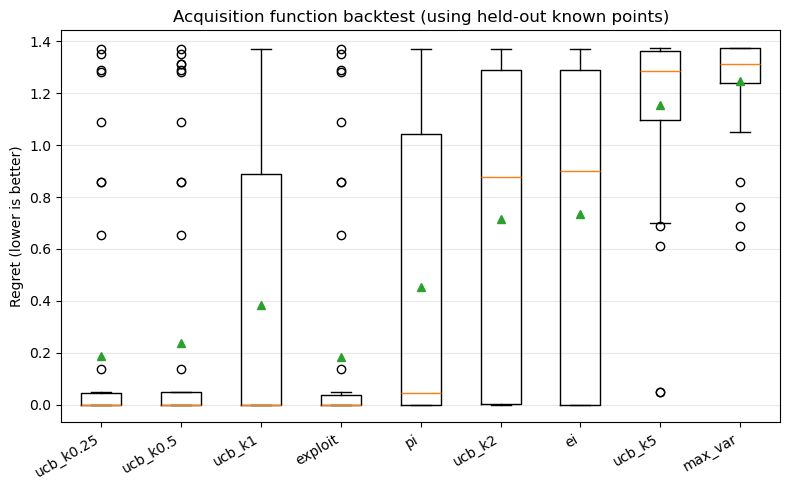

In [7]:
xi_raw = 0.01 * (y.max() - y.min())
backtest_configs = [
    {"name": "ucb_k0.25", "acquisition": "ucb", "kappa": 0.25},
    {"name": "ucb_k0.5", "acquisition": "ucb", "kappa": 0.5},
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k2",   "acquisition": "ucb", "kappa": 2.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "ei",       "acquisition": "ei",  "xi": xi_raw},
    {"name": "pi",       "acquisition": "pi",  "xi": xi_raw},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]
print(f"xi for the PI/EI rows: {xi_raw:.6f} (1% of the y spread)")

# Is xi a live dial here, or degenerate? Checked rather than assumed.
print("\nis xi a live dial? (proposal movement as xi grows)")
_prev = {}
for _acq in ("ei", "pi"):
    for _frac in (0.001, 0.05, 1.0):
        _xi = _frac * (y.max() - y.min())
        with fitting(f"{_acq} at xi={_frac:.1%} of spread"):
            _p, _ = generate_next_point(X, y, bounds, acquisition=_acq, xi=_xi,
                                        maximize=True, n_restarts=40, random_state=0)
        _m, _ = gp_check.predict(normalize(_p.reshape(1, -1), bounds), return_std=True)
        _mv = "" if _acq not in _prev else f"  moved {np.linalg.norm(_p - _prev[_acq]):.4f}"
        print(f"  {_acq} xi={_frac:>6.1%} of spread: pred mean {_m[0]:+.4f}{_mv}")
        _prev[_acq] = _p
print("  -> xi IS live here, but both families degrade the predicted mean, so they")
print("     are variance-seeking on this function rather than degenerate.\n")

with fitting("acquisition backtest, 50 splits"):
    backtest_results = backtest_acquisitions(
        X, y, bounds, backtest_configs,
        n_repeats=50, seed_frac=0.5, maximize=True,
        gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
    )

print_backtest_summary(backtest_results)

# Which acquisition looks best so far. Configs are compared PAIRED on the same
# splits, so "within noise" below means |mean difference| <= 2 standard errors --
# plain arithmetic, no statistical test. Read it knowing the metric scores
# RECOGNITION of points whose y is already known, which is an exploitation task.
CHOSEN = "exploit"        # must name the committed KAPPA; asserted where KAPPA is set

assert CHOSEN in backtest_results, (
    f"{CHOSEN!r} is not among the backtest configs, so the committed setting is "
    f"never scored. Add a row for it. Have: {sorted(backtest_results)}"
)

names = list(backtest_results)
mean_r = {k: float(backtest_results[k]["regret"].mean()) for k in names}
med_r = {k: float(np.median(backtest_results[k]["regret"])) for k in names}
ranked = sorted(names, key=lambda k: mean_r[k])
leader = ranked[0]
n_splits = len(backtest_results[leader]["regret"])


def paired_gap(a, b):
    """Mean per-split regret difference (b - a), and its standard error."""
    d = backtest_results[b]["regret"] - backtest_results[a]["regret"]
    return float(d.mean()), float(d.std(ddof=1) / np.sqrt(len(d)))


tied = [k for k in ranked[1:]
        if abs(paired_gap(leader, k)[0]) <= 2 * paired_gap(leader, k)[1]]
worse = [k for k in ranked[1:] if k not in tied]

print("\n=== which acquisition appears best in our tests so far? ===")
print(f"leader by mean regret   : {leader:>10}  ({mean_r[leader]:.4f})")
best_med = min(names, key=lambda k: med_r[k])
print(f"leader by median regret : {best_med:>10}  ({med_r[best_med]:.4f})"
      + ("   (agrees)" if best_med == leader else "   (DISAGREES with the mean)"))

print(f"\npaired against {leader}, over the same {n_splits} splits:")
for k in ranked[1:]:
    gap, se = paired_gap(leader, k)
    print(f"  {k:>10}: {gap:+.4f} +/- {se:.4f} ({gap / se:>5.1f} s.e.)"
          f"   {'within noise' if k in tied else 'clearly worse'}")

print(f"\nindistinguishable from the leader : {', '.join([leader] + tied)}")
print(f"clearly worse                     : {', '.join(worse) or 'none'}")

rank = ranked.index(CHOSEN) + 1
gap, se = paired_gap(leader, CHOSEN)
print(f"\nthis notebook proposes with {CHOSEN}: ranked {rank} of {len(ranked)}", end="")
if CHOSEN == leader:
    print(" -- it leads.")
else:
    print(f", {gap:+.4f} +/- {se:.4f} behind {leader}"
          f" ({'within noise' if CHOSEN in tied else 'a REAL gap'}).")
print("Do NOT switch on this table alone -- see the bias note above, and check")
print("where each candidate would actually propose before acting on it.")

plot_acquisition_backtest(backtest_results)
plt.show()


## Comparing kappa before I commit

Two views.

First `compare_kappa_proposals`, unrestricted over all six axes — shown to demonstrate *why* the restriction is needed. It is free to move x1 and x2, and whatever it does with them is an optimiser artefact on a flat surface: watch them wander to 0.39, 0.34, 0.17 and then to the corners `[0, 1]` as `kappa` rises, with no bearing on the prediction.

Then the restricted search over the live axes only, which is what I make the choice from.

**My criterion is the largest `kappa` whose predicted mean still beats the incumbent, and here nothing does** — so `kappa = 0` is the value that loses least. I used to use "the largest `kappa` touching no bound, upper or lower", which rested on upper contact meaning `pad_fraction` had chosen the coordinate. Bounds are the true domain now, so that reading is void; and on this data it would not even discriminate, since `kappa` 0 through 1.0 all touch nothing and it would therefore have picked 1.0, the worst of them.

Bound contact is still reported per edge, because the two mean different things — a coordinate on the `0.0` floor says the acquisition wants to leave the feasible region, while one at 1.0 says the constrained optimum sits on the boundary. Neither is automatically a defect; I judge it against whether that axis is monotone toward that end.

=== unrestricted over all 6 axes (shown to demonstrate the problem) ===


[fitting: kappa sweep (one shared GP)] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
   kappa |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
    0.25 | [0.049,0.39 ,0.313,0.189,0.392,0.714] |     1.3854 |     1.3701 |    0.0612 |          0.1353
     0.5 | [0.05 ,0.341,0.343,0.18 ,0.389,0.708] |     1.4021 |     1.3658 |    0.0726 |          0.1918
       1 | [0.039,0.166,0.453,0.161,0.383,0.693] |     1.4446 |     1.3465 |    0.0981 |          0.3939
       2 | [0.   ,0.   ,1.   ,0.12 ,0.374,0.664] |     1.5691 |     1.2712 |    0.1490 |          0.9078
       5 | [0.   ,0.   ,1.   ,0.   ,0.346,0.607] |     2.1748 |     0.9948 |    0.2360 |          0.9362

what the unrestricted search does with the FL

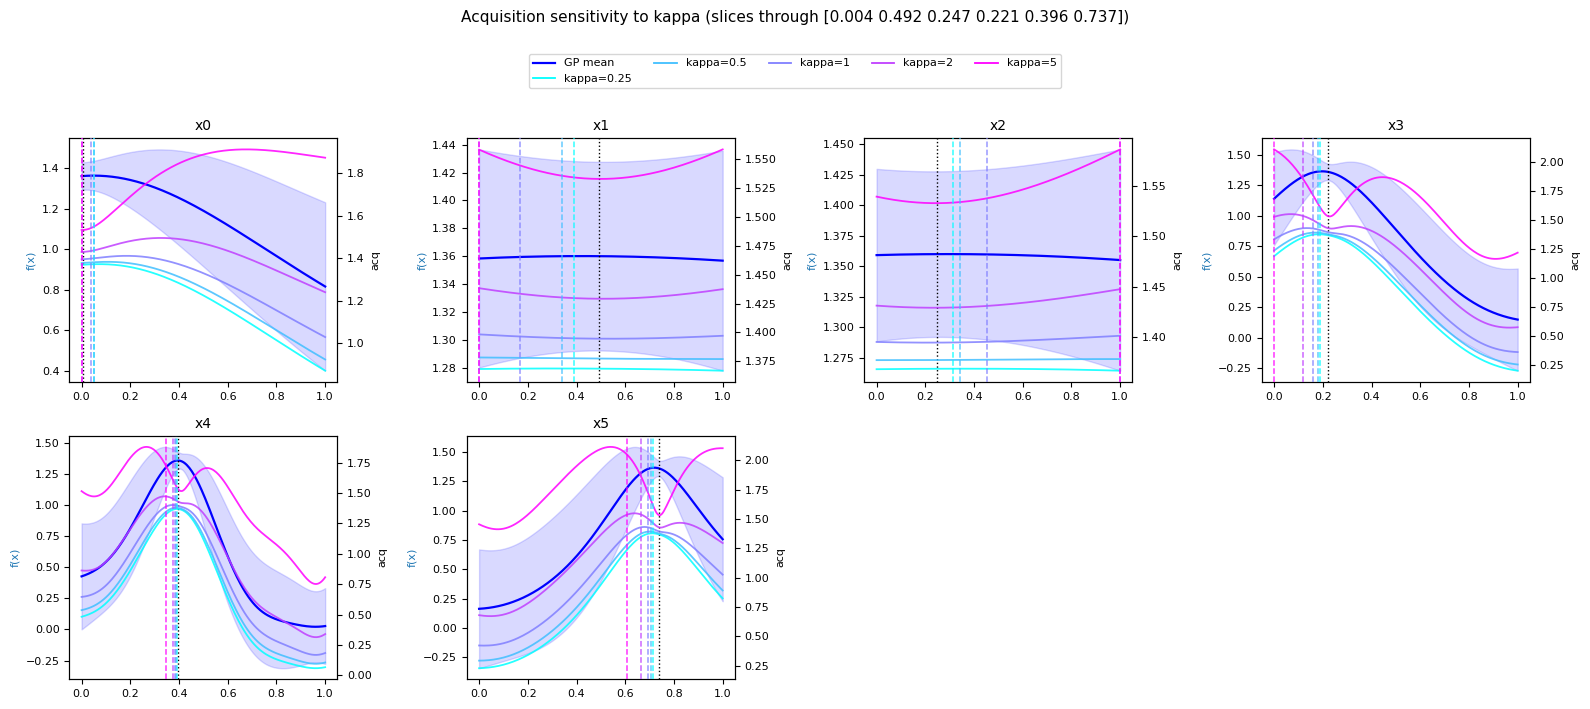


=== restricted to the live axes x[0, 3, 4, 5] (what the choice is made from) ===
 kappa |  pred mean |  pred std |    UPPER bnd |    lower bnd |    dist
     0 |   +1.37126 |   0.05147 |         none |         none |  0.0505
  0.25 |   +1.37002 |   0.06106 |         none |         none |  0.0600


   0.5 |   +1.36576 |   0.07235 |         none |         none |  0.0691
     1 |   +1.34670 |   0.09763 |         none |         none |  0.0841


     2 |   +1.27166 |   0.14820 |         none |          [0] |  0.1294
incumbent y = 1.374343

using kappa = 0.0 (= exploit), searching only x[0, 3, 4, 5]
chosen as the kappa that loses least: every value predicts a LOSS against
the incumbent (1.374343), so there is no largest-with-a-gain to take.


In [8]:
def bound_report(p):
    """Report which coordinates sit on a domain edge, upper and lower separately.

    Bounds are the true domain [0,1], so NEITHER edge is automatically a defect
    -- contact means the constrained optimum is on the boundary, which on a
    monotone axis is exactly right. I judge it per axis against that axis's
    monotone direction (see the axis cell), not by which edge it is.
    """
    upper = [d for d in range(D) if np.isclose(p[d], bounds[d, 1])]
    lower = [d for d in range(D) if np.isclose(p[d], bounds[d, 0])]
    return upper, lower


print("=== unrestricted over all 6 axes (shown to demonstrate the problem) ===")
with fitting("kappa sweep (one shared GP)"):
    kappa_rows = compare_kappa_proposals(X, y, bounds, kappa_values=[0.25, 0.5, 1.0, 2.0, 5.0],
                                          maximize=True, n_restarts=40, random_state=0)

print_kappa_comparison(kappa_rows)
print("\nwhat the unrestricted search does with the FLAT axes"
      f" x{flat} (incumbent has {np.round(incumbent[flat], 4)}):")
for row in kappa_rows:
    print(f"  kappa={row['kappa']:<5g} flat-axis values {np.round(row['x_next'][flat], 4)}"
          f"  <- arbitrary; the acquisition is flat along these")

plot_kappa_sensitivity(X, y, bounds, gp_check, kappa_rows, ucb_acquisition, maximize=True)
plt.show()


def restricted_ucb(kappa, n_starts=80):
    """Maximise UCB over the live axes only, holding flat axes at the incumbent."""
    lo = bounds[live, 0]
    hi = bounds[live, 1]

    def neg(v):
        p = incumbent.copy()
        p[live] = v
        return -ucb_acquisition(normalize(p.reshape(1, -1), bounds), gp_check,
                                 kappa=kappa, maximize=True)[0]

    best_val, best_v = np.inf, None
    rng = np.random.default_rng(0)
    for start in rng.uniform(lo, hi, size=(n_starts, len(live))):
        res = minimize(neg, start, method="L-BFGS-B", bounds=list(zip(lo, hi)))
        if res.fun < best_val:
            best_val, best_v = res.fun, res.x
    p = incumbent.copy()
    p[live] = best_v
    m, s = gp_check.predict(normalize(p.reshape(1, -1), bounds), return_std=True)
    return p, m[0], s[0]


print(f"\n=== restricted to the live axes x{live} (what the choice is made from) ===")
print(f"{'kappa':>6} | {'pred mean':>10} | {'pred std':>9} | {'UPPER bnd':>12}"
      f" | {'lower bnd':>12} | {'dist':>7}")
for k in [0.0, 0.25, 0.5, 1.0, 2.0]:
    p, m, s = restricted_ucb(k)
    up, lo_ = bound_report(p)
    print(f"{k:6g} | {m:+10.5f} | {s:9.5f} | {str(up) if up else 'none':>12}"
          f" | {str(lo_) if lo_ else 'none':>12} | {np.linalg.norm(p - incumbent):7.4f}")
print(f"incumbent y = {y.max():.6f}")

# My choice, defined here so the proposal, the slice plot and the diagnostics
# replay all read one value and can't drift apart.
#
# kappa = 0 is `exploit`: UCB with kappa=0 is exactly the posterior mean. Chosen
# because NO kappa predicts a gain over the incumbent (see the table above), so
# this is the value that loses LEAST rather than a positive expectation.
#
# My previous criterion -- "largest kappa touching no bound, upper or lower" --
# rested on upper contact being a pad_fraction artifact, which is false now that
# bounds are the domain. It also does not discriminate on this data: kappa 0
# through 1.0 all touch nothing, so it would have picked 1.0, the worst of them.
KAPPA = 0.0
print(f"\nusing kappa = {KAPPA} (= exploit), searching only x{live}")
print(f"chosen as the kappa that loses least: every value predicts a LOSS against")
print(f"the incumbent ({y.max():.6f}), so there is no largest-with-a-gain to take.")

# The verdict cell above reports how the committed setting ranks, which only
# means something if CHOSEN names this KAPPA. Config names follow
# f"ucb_k{kappa:g}", so this is checkable rather than a comment to remember.
# UCB at kappa=0 IS exploit (mu + 0*sigma), and the backtest scores it
# under that name, so map it accordingly.
_expected = "exploit" if KAPPA == 0 else f"ucb_k{KAPPA:g}"
assert CHOSEN == _expected, (
    f"CHOSEN={CHOSEN!r} does not match the committed KAPPA={KAPPA}"
    f" (expected {_expected!r}). The backtest verdict above refers to a config"
    " this notebook does not use -- fix one or the other."
)


## Propose the next point

The live axes come from the restricted UCB search; x1 and x2 are held at the incumbent because the acquisition is flat along them.

Expect a small step — 0.0505 — and note that this is now a *different argument* from the one I made last week. Then I justified staying close because the incumbent was a peak the model could not reproduce when held out. It reproduces it now (z = +1.0), and week 4 independently confirmed the region. So the step is small because **the function looks converged and no `kappa` predicts a gain**, not because the peak is unexplained.

In [9]:
x_next, mu_next, sigma_next = restricted_ucb(KAPPA, n_starts=150)
gp = gp_check

print(f"--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu_next:.6f}, predicted std: {sigma_next:.6f}")
print(f"current best observed y: {y.max():.6f}"
      f"  -> predicted improvement: {mu_next - y.max():+.6f}")
print(f"flat axes x{flat} held at the incumbent:"
      f" {np.allclose(x_next[flat], incumbent[flat])}")

# Bounds are the TRUE DOMAIN, so neither edge is automatically a defect. The
# question is whether the axis is monotone toward that edge (expected) or not
# (worth questioning).
up, lo = bound_report(x_next)
for label, dims, is_upper in (("UPPER", up, True), ("lower", lo, False)):
    print(f"\non the {label} domain edge:", dims or "none")
    for d in dims:
        toward = (srho[d] > 0) == is_upper
        if abs(srho[d]) > 0.4 and toward:
            print(f"  x{d}: EXPECTED -- monotone (spearman {srho[d]:+.3f}) with its"
                  " best end at this edge")
        else:
            print(f"  x{d}: QUESTION IT -- spearman {srho[d]:+.3f} does not point this"
                  " way, so the edge may be the optimiser stopping, not an optimum")

outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("outside the observed range on its own axis:", outside or "none")
if hull is not None:
    print(f"inside the convex hull: {bool(hull.find_simplex(x_next) >= 0)}"
          "  (nearly vacuous at D=6 -- see above)")

print(f"\ndistance from the incumbent: {np.linalg.norm(x_next - incumbent):.6f}")
print("for comparison, the week-2 proposal was"
      f" {np.linalg.norm(new_X[0] - X_initial[np.argmax(y_initial)]):.4f} from the"
      " then-incumbent and returned the worst y on record; the week-3 proposal"
      f" was {np.linalg.norm(new_X[-1] - X_initial[np.argmax(y_initial)]):.4f}"
      " away and returned the best")
print("\nnearest 3 observations to x_next:")
for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:3]:
    print(f"  dist={np.linalg.norm(X[i] - x_next):.4f}  y={y[i]:+.6f}  X={np.round(X[i], 3)}")

--- Next point to evaluate (bounds shape (6, 2)) ---
x_next: [0.044754 0.491672 0.247422 0.197315 0.39486  0.719635]
0.801**2 * Matern(length_scale=[1.04, 10, 10, 0.382, 0.208, 0.255], nu=2.5) + WhiteKernel(noise_level=0.0047)
GP predicted mean: 1.371264, predicted std: 0.051474
current best observed y: 1.374343  -> predicted improvement: -0.003079
flat axes x[1, 2] held at the incumbent: True

on the UPPER domain edge: none

on the lower domain edge: none
outside the observed range on its own axis: none
inside the convex hull: False  (nearly vacuous at D=6 -- see above)

distance from the incumbent: 0.050460
for comparison, the week-2 proposal was 1.8343 from the then-incumbent and returned the worst y on record; the week-3 proposal was 0.0619 away and returned the best

nearest 3 observations to x_next:
  dist=0.0373  y=+1.364968  X=[0.058 0.492 0.247 0.218 0.42  0.731]
  dist=0.0505  y=+1.374343  X=[0.004 0.492 0.247 0.221 0.396 0.737]
  dist=0.0613  y=+1.327096  X=[0.    0.492 0.24

## Visualise the GP and acquisition function via 1D slices

Each panel holds the other five dimensions at the current best observed point and sweeps one. Dotted line is the fixed centre, dashed red is `x_next`, green is UCB.

I expect the **x1 and x2 panels to be essentially flat lines** — their range is about 0.005 against roughly 1.2–1.3 for the other four. That flatness is the model, not a plotting bug, and it is exactly why those two coordinates are pinned at the incumbent rather than optimised.

The x0, x3, x4 and x5 panels should each show structure on a comparable scale, which is why I search all four rather than reducing to one axis.

A partial view: the GP along each axis near the best point, not interactions between dimensions.

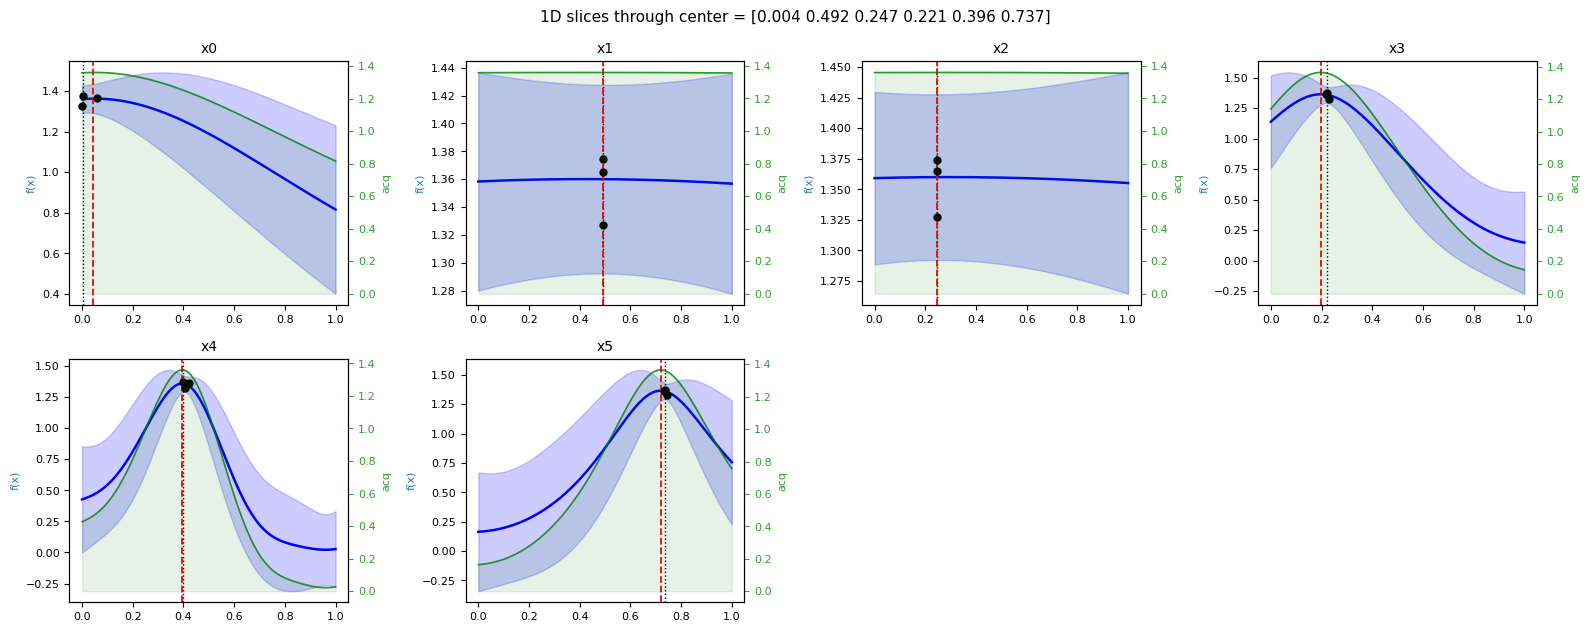

In [10]:
plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
)
plt.show()

## Sanity-check the surrogate: leave-one-out calibration

Refits once per observation, holding it out and predicting it from the rest. At D=6 this is my main way to judge the surrogate.

**This cell used to carry the opposite conclusion and it is worth recording why.** It said the worst-predicted point "should be the incumbent", held out at roughly `0.203 ± 0.086` against a true `1.365` — a ~13.5 sigma miss — and used that to argue the peak rested on a single unexplainable measurement. On current data the incumbent predicts `+1.3324 ± 0.0409` against `1.3743`, so **z = +1.0**, and the worst-predicted point is index 3 — an initial-batch point, at −4.5 sigma. So the cell now reports which point is actually worst rather than asserting which one it ought to be.

Coverage is 29/33 inside their own 95% interval, reasonable at this sample size.

`random_state` is pinned here, and that matters more than it looks. `gp_kwargs` is forwarded to `fit_gp` on every one of the 33 refits, so unseeded this cell was not reproducible — two consecutive runs gave 29/33 with the worst point at index 7 (−2.5σ) and 28/33 with index 3 (−4.5σ). A claim about *which* point is worst is meaningless unless it is seeded.

[fitting: leave-one-out calibration] 68 warnings held back, 4 distinct:
    33 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
    29 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     3 x  ConvergenceWarning  k1__k2__length_scale (dim 3) pinned at upper bound 10.0
     3 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06


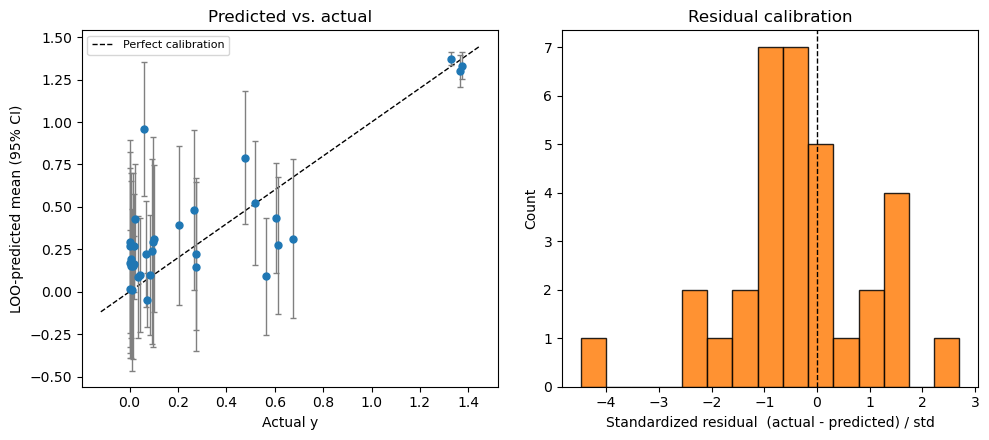

points inside their own 95% LOO interval: 29/33
worst-predicted: index 3 -> true 0.061424, predicted 0.960577 (std 0.200733) = -4.5 sigma
is that the incumbent (the best observation)? False
that point comes from the initial batch


In [11]:
# random_state is pinned. Without it this cell was not reproducible: gp_kwargs
# goes to fit_gp for every refit, so 33 unseeded multi-restart optimisations gave
# a different answer each run -- two consecutive runs reported 29/33 with the
# worst point at index 7 (-2.5 sigma) and 28/33 with index 3 (-4.5 sigma). The
# markdown states which point is worst, so that number has to be stable.
with fitting("leave-one-out calibration"):
    pred_mean, pred_std = loo_predictions(
        X, y, bounds, gp_kwargs={"n_restarts_optimizer": 20, "random_state": 0})

plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")
worst = int(np.argmax(np.abs(y - pred_mean)))
print(f"worst-predicted: index {worst} -> true {y[worst]:.6f},"
      f" predicted {pred_mean[worst]:.6f} (std {pred_std[worst]:.6f})"
      f" = {(y[worst] - pred_mean[worst]) / pred_std[worst]:+.1f} sigma")
# Report WHICH row it is rather than testing `worst == n_initial`, which only
# ever asked about week 2 and quietly stopped meaning anything once there were
# three collected rows.
print("is that the incumbent (the best observation)?", worst == int(np.argmax(y)))
_src = ("the initial batch" if worst < n_initial
        else f"collected week {worst - n_initial + 2}")
print(f"that point comes from {_src}")


## Iteration diagnostics

Replays the ordered `X`/`y` to reconstruct what the acquisition value, GP hyperparameters and domain-wide uncertainty were at each past proposal. No persisted log involved.

**I have to lower `domain_grid_n` at this dimensionality.** Its `domain_mean_std` field averages posterior std over a `domain_grid_n ** D` grid, so the default 40 means `40**6 = 4.1e9` points — roughly **197 GB**, which kills the kernel outright. The cell sizes the grid so the count stays near 200,000 whatever `D` is, giving 7 here. `domain_mean_std` is therefore coarse: fine for comparing iterations within this run, not comparable against a run that used a different grid.

Two caveats. The `kappa` comes from `KAPPA` so it cannot drift from what the proposal used, but my history is **mixed** — week 2 came from the original template's settings and weeks 3–4 from `ucb`/`kappa=0.25`, none of them from the committed `kappa=0`. `compute_iteration_diagnostics` applies one setting across the whole replay, so the `acq_value` column is an artefact of that mismatch rather than a property of any point. The GP-hyperparameter and `domain_mean_std` columns don't depend on the acquisition and are fine throughout.

`plot_bo_diagnostics` is skipped, since it hard-codes a 2D scatter panel. The trend plots below are dimension-agnostic and gated on having at least three completed iterations.

domain_grid_n = 7 -> 117,649 grid points (the default 40 would be 4,096,000,000)


[fitting: iteration-diagnostics replay] 7 warnings held back, 3 distinct:
     3 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     3 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06

Best y so far: 1.3743434016209042
completed iterations in the modelling set: 3

CAVEAT: my history is MIXED -- week 2 came from the original template's
settings and weeks 3-4 from ucb/kappa=0.25, none of them from the committed
kappa=0.0. compute_iteration_diagnostics applies ONE setting across the whole
replay, so acq_value is an artefact of that mismatch rather than a property of
any point. The GP-hyperparameter and domain_mean_std columns don't depend on
the acquisition and are fine throughout.


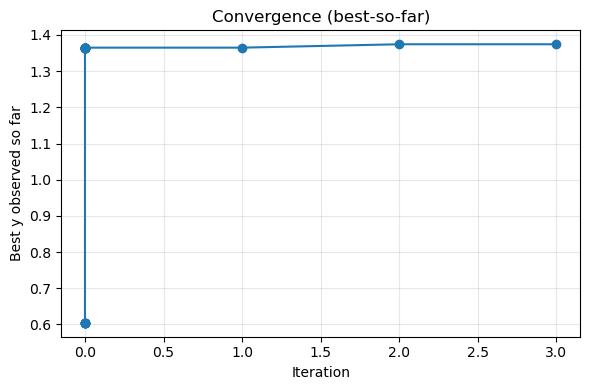

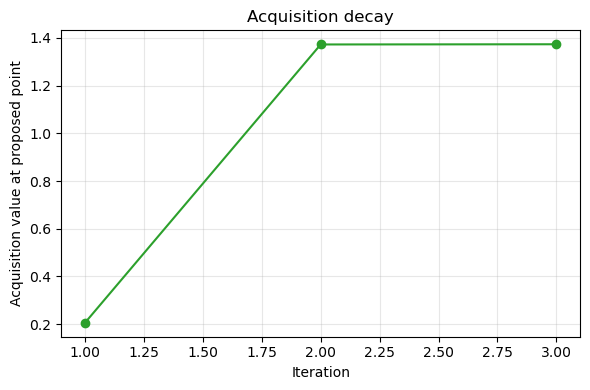

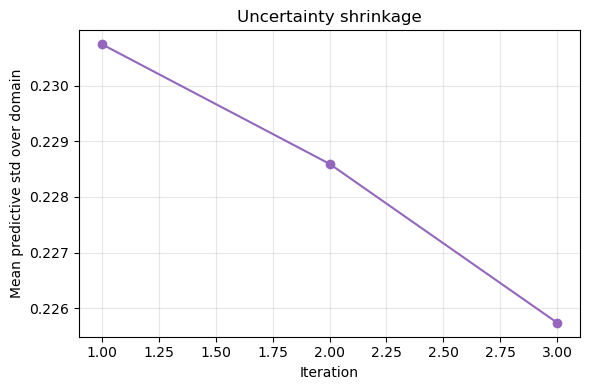

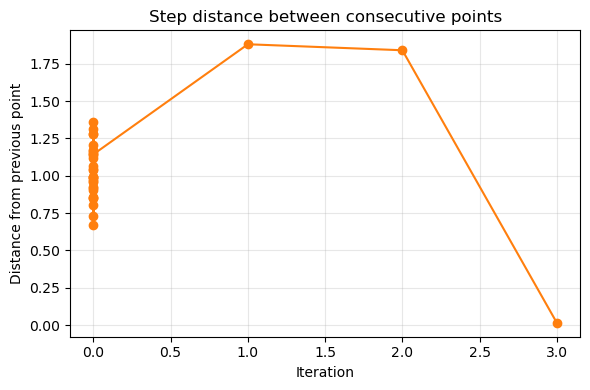

In [12]:
# compute_iteration_diagnostics builds a domain_grid_n ** D grid. The default 40
# is 40**6 = 4.1e9 points (~197 GB) at D=6 and WILL kill the kernel. Size it so
# the grid stays near 200k points whatever D is.
DOMAIN_GRID_N = max(3, int(200_000 ** (1.0 / D)))
print(f"domain_grid_n = {DOMAIN_GRID_N} -> {DOMAIN_GRID_N ** D:,} grid points"
      f" (the default 40 would be {40 ** D:,})")

# The count comes from the MODELLING set rather than len(new_y), so it stays
# correct if I ever exclude rows from the fit.
n_replayed = len(y) - n_initial

with fitting("iteration-diagnostics replay"):
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                            acquisition="ucb", kappa=KAPPA,
                                            maximize=True,
                                            domain_grid_n=DOMAIN_GRID_N)

print("\nBest y so far:", np.nanmax(history["y"]))
print("completed iterations in the modelling set:", n_replayed)
print(f"\nCAVEAT: my history is MIXED -- week 2 came from the original template's")
print("settings and weeks 3-4 from ucb/kappa=0.25, none of them from the committed")
print(f"kappa={KAPPA}. compute_iteration_diagnostics applies ONE setting across the whole")
print("replay, so acq_value is an artefact of that mismatch rather than a property of")
print("any point. The GP-hyperparameter and domain_mean_std columns don't depend on")
print("the acquisition and are fine throughout.")

if n_replayed >= 3:
    for plot_fn in (plot_convergence, plot_acquisition_decay,
                    plot_uncertainty_shrinkage, plot_step_distance):
        plot_fn(history)
        plt.show()
else:
    print(f"\nOnly {n_replayed} replayed iteration(s) -- need at least 3 before the")
    print("trend plots say anything. Skipping them; the raw fields are below.")

## Raw diagnostic fields

In [13]:
print("y:", np.round(history["y"], 6))
print("\niteration:", history["iteration"])
print("\nacq_value (NaN = initial batch; see the caveat above):", history["acq_value"])
print("\npred_mean at proposal time:", history["pred_mean"])
print("\ndomain_mean_std:", history["domain_mean_std"])

y: [6.044330e-01 5.627530e-01 7.503000e-03 6.142400e-02 2.730470e-01
 8.374700e-02 1.364968e+00 9.264500e-02 1.787000e-02 3.356500e-02
 7.351600e-02 2.063100e-01 8.826000e-03 2.684000e-01 6.115260e-01
 1.479800e-02 2.748930e-01 6.676300e-02 4.211800e-02 2.701000e-03
 1.820900e-02 7.016000e-03 1.005070e-01 4.753960e-01 6.751420e-01
 5.164570e-01 3.777000e-03 3.134000e-03 2.134300e-02 9.541100e-02
 3.090000e-04 1.374343e+00 1.327096e+00]

iteration: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 2. 3.]

acq_value (NaN = initial batch; see the caveat above): [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
 0.20567448 1.37287847 1.37374359]

pred_mean at propos

In [14]:
# My proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision too. I submit the 6-dp string; the store keeps 6 dp as well,
# which is what actually gets evaluated.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.044754-0.491672-0.247422-0.197315-0.394860-0.719635

full precision (use for next week's new_X):
0.04475371281690102-0.491672-0.247422-0.1973154999121615-0.3948596438172216-0.7196345819599618


In [15]:
# I record this week's proposal in the weekly store. This rewrites inputs.csv
# rather than appending, so re-running the notebook cannot double-record. I
# submit the 6-dp string printed above -- it is the same value written here.
save_proposal(7, new_X, x_next)


wrote weekly_data/function_7/inputs.csv: 4 row(s) (3 resulted + 1 proposal)
  proposal row: 0.044754-0.491672-0.247422-0.197315-0.394860-0.719635


'weekly_data/function_7/inputs.csv'